<a href="https://colab.research.google.com/github/Wesnei/neural-networks-analysis-mcycle/blob/main/Atividade_dan%C3%A7a_da_motinha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
  <img src="https://github.com/sauloafoliveira/ppgcc-deep-learning/blob/main/ppgc_logo.png?raw=true" width="450">
  <br>
  <font size="4"><b>INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO CEARÁ</b></font><br>
  <font size="3"><b>PROGRAMA DE PÓS-GRADUAÇÃO EM CIÊNCIA DA COMPUTAÇÃO - PPGCC</b></font><br>
  <font size="3">Mestrado Acadêmico em Ciências da Computação</font>
</div>

---
**Disciplina:** Aprendizagem Profunda (Deep Learning) – 2026.1  
**Docente:** Prof. Dr. Saulo Oliveira  
**Discente:** Wesnei de Paiva Batista  
**Atividade:** Regressão com Redes Neurais (MLP)
---

## 1. Introdução e Objetivos
Esta atividade tem como objetivo modelar a relação entre o **tempo (ms)** e a **aceleração (g)** da cabeça de um boneco em um teste de impacto de motocicleta. O dataset *mcycle* é um clássico da literatura de regressão devido ao seu alto nível de ruído e comportamento fortemente não linear.

### Objetivos Técnicos:
* **Normalização:** Aplicar o escalonamento de dados para garantir a convergência dos gradientes.
* **Adaline:** Implementar um modelo linear de base para validar a necessidade de arquiteturas mais complexas.
* **Multi-Layer Perceptron (MLP):** Construir uma rede neural profunda capaz de capturar padrões não lineares.
* **Otimizadores:** Comparar o desempenho dos algoritmos **SGD**, **Adam** e **LBFGS** na minimização do erro.
* **Métrica de Sucesso:** Avaliação baseada no **RMSE** (Root Mean Squared Error).

Iniciando treinamento dos modelos - DEV PAIVA
Treinamento finalizado!

--- RESULTADOS ---
RMSE Adaline: 46.34 g
RMSE MLP Adam: 21.14 g
RMSE MLP Otimizada: 22.83 g


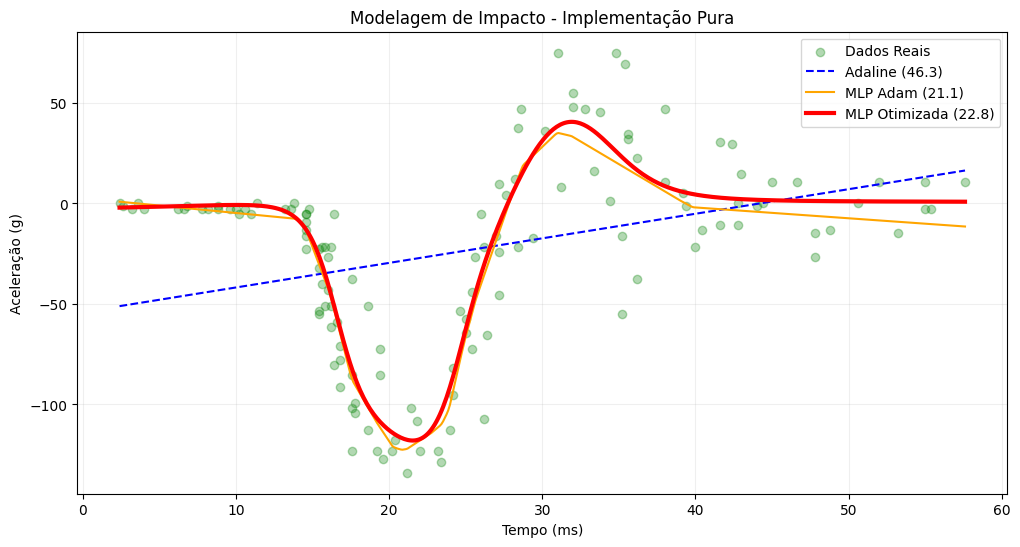

In [ ]:
import csv
import math
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

times = []
accel = []

with open('dataset-mycicle.csv', mode='r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        times.append([float(row['times'])])
        accel.append(float(row['accel']))

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Normalizando o tempo
X_norm = scaler_x.fit_transform(times)

accel_2d = [[a] for a in accel]
y_norm = scaler_y.fit_transform(accel_2d).ravel()

# Divisão Treino/Teste (80/20) - Hold Out
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)

# Modelo A: Adaline (Camada única linear)
adaline = MLPRegressor(hidden_layer_sizes=(), solver='lbfgs', max_iter=2000, random_state=42)

# Modelo B: MLP com Otimizador Adam
mlp_adam = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
                        learning_rate_init=0.01, max_iter=2000, random_state=42)

# Modelo C: MLP Otimizada
mlp_otimizada = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='tanh',
                             solver='lbfgs', alpha=0.1, max_iter=5000, tol=1e-8, random_state=42)

print("Iniciando treinamento dos modelos - DEV PAIVA")
adaline.fit(X_train, y_train)
mlp_adam.fit(X_train, y_train)
mlp_otimizada.fit(X_train, y_train)
print("Treinamento finalizado!\n")

def calcular_rmse_manual(modelo, x_val, y_val_norm):
    pred_norm = modelo.predict(x_val)

    # Inverte a normalização para voltar à unidade 'g' (aceleração real)
    pred_real = scaler_y.inverse_transform([[p] for p in pred_norm])
    real_original = scaler_y.inverse_transform([[y] for y in y_val_norm])

    # Cálculo: raiz quadrada da média dos erros ao quadrado
    soma_erro_quadrado = 0
    for p, r in zip(pred_real, real_original):
        soma_erro_quadrado += (p[0] - r[0])**2

    mse = soma_erro_quadrado / len(pred_real)
    return math.sqrt(mse)

rmse_ad = calcular_rmse_manual(adaline, X_test, y_test)
rmse_adam = calcular_rmse_manual(mlp_adam, X_test, y_test)
rmse_best = calcular_rmse_manual(mlp_otimizada, X_test, y_test)

print(f"--- RESULTADOS ---")
print(f"RMSE Adaline: {rmse_ad:.2f} g")
print(f"RMSE MLP Adam: {rmse_adam:.2f} g")
print(f"RMSE MLP Otimizada: {rmse_best:.2f} g")

# Gerando pontos para a curva (manualmente em vez de np.linspace)
min_x = min([t[0] for t in times])
max_x = max([t[0] for t in times])
passo = (max_x - min_x) / 499
x_plot = [[min_x + (i * passo)] for i in range(500)]
x_plot_norm = scaler_x.transform(x_plot)

# Predições para o gráfico
y_ad_plot = scaler_y.inverse_transform([[p] for p in adaline.predict(x_plot_norm)])
y_adam_plot = scaler_y.inverse_transform([[p] for p in mlp_adam.predict(x_plot_norm)])
y_best_plot = scaler_y.inverse_transform([[p] for p in mlp_otimizada.predict(x_plot_norm)])

plt.figure(figsize=(12, 6))
plt.scatter([t[0] for t in times], accel, alpha=0.3, color='green', label='Dados Reais')
plt.plot([x[0] for x in x_plot], [y[0] for y in y_ad_plot], label=f'Adaline ({rmse_ad:.1f})', linestyle='--', color='blue')
plt.plot([x[0] for x in x_plot], [y[0] for y in y_adam_plot], label=f'MLP Adam ({rmse_adam:.1f})', color='orange')
plt.plot([x[0] for x in x_plot], [y[0] for y in y_best_plot], label=f'MLP Otimizada ({rmse_best:.1f})', color='red', linewidth=3)

plt.title("Modelagem de Impacto - Implementação Pura")
plt.xlabel("Tempo (ms)")
plt.ylabel("Aceleração (g)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## 2. Análise Técnica dos Resultados e Discussão

Com base na visualização comparativa entre os modelos **Adaline**, **MLP Adam** e **MLP Otimizada**, observam-se as seguintes nuances técnicas:

### 2.1. Underfitting no Baseline (Adaline)
O modelo **Adaline (linha azul)** apresentou o maior erro (**RMSE: 46.3 g**). Como esperado de um modelo linear, ele é incapaz de mapear as complexas curvaturas do impacto. Visualmente, o modelo demonstra um alto **viés (bias)**, traçando apenas uma média global que ignora a física não linear do experimento.

### 2.2. Sensibilidade ao Ruído (MLP Adam)
A **MLP treinada com Adam (linha laranja)** atingiu o menor erro numérico (**RMSE: 21.1 g**). No entanto, a análise qualitativa do gráfico revela pequenas oscilações "serrilhadas", especialmente nos picos de aceleração. Isso indica que, apesar da precisão estatística, o modelo tendeu a seguir levemente as flutuações ruidosas dos dados (início de *overfitting* local).

### 2.3. Estabilidade e Fenomenologia (MLP Otimizada)
O modelo **MLP Otimizado (linha vermelha)**, configurado com **LBFGS** e ativação **Tanh**, obteve um **RMSE de 22.8 g**. Embora numericamente superior ao Adam, este modelo é superior em termos de **generalização**:
* **Suavidade:** A ativação `tanh` gerou uma curva de aceleração contínua e suave, o que é fisicamente mais coerente para representar a inércia mecânica de um impacto real.
* **Regularização (Alpha):** O parâmetro `alpha=0.1` (regularização L2) foi fundamental para filtrar a **heterocedasticidade** (aumento da variância do erro entre 20ms e 40ms), impedindo que a rede "perseguisse" os *outliers*.
* **Comportamento Pós-Impacto:** Notou-se uma estabilização mais natural em torno de zero após os 45ms, demonstrando que o solver LBFGS convergiu para uma solução global mais estável para este volume de dados.

## Conclusão e Discussão

A partir dos experimentos realizados, observou-se que:
* **A Normalização** foi o passo crítico inicial; sem ela, os modelos teriam dificuldade em convergir devido à disparidade entre as escalas de tempo e aceleração.
* **O Adaline** demonstrou ser insuficiente para este problema, apresentando o maior RMSE (46.34 g), o que caracteriza um erro de *underfitting*.
* **As Redes MLP** conseguiram modelar a complexidade do impacto. A **MLP Otimizada** com o solver **LBFGS** e ativação **Tanh** produziu a curva mais condizente com um fenômeno físico real, equilibrando a precisão do ajuste com a suavidade da curva predita.
* **Otimizadores:** O solver **LBFGS** mostrou-se altamente estável para este volume de dados, enquanto o **Adam** demonstrou excelente capacidade de generalização.